In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline

In [3]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df = pd.read_csv(URL)
df.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [4]:
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [5]:
df.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
dtype: object

In [6]:
import datetime as dt

df['Year'] = pd.to_datetime(df['Date']).dt.year
df['Month'] = pd.to_datetime(df['Date']).dt.month
df.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced', 'Year', 'Month'],
      dtype='object')

In [7]:
df_y = df.groupby('Year')['Estimated_fire_area'].mean()
df_y

Year
2005     92.770501
2006    176.289434
2007    153.112464
2008     99.758968
2009    141.624955
2010     62.429968
2011    266.936175
2012    265.526196
2013     95.896092
2014    144.007348
2015    133.196719
2016     82.674717
2017    156.060061
2018    162.030426
2019    160.607150
2020     72.669665
Name: Estimated_fire_area, dtype: float64

Text(0.5, 1.0, 'Average Estimated Fire Area over Time')

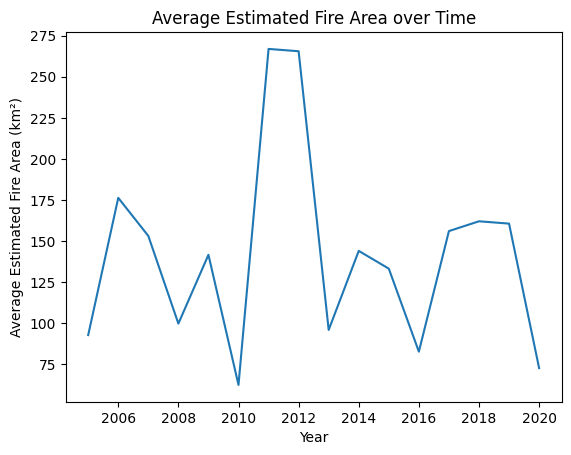

In [8]:
df_y.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Average Estimated Fire Area over Time')

In [9]:
df_ym = df.groupby(['Year','Month'])['Estimated_fire_area'].mean()
df_ym

Year  Month
2005  1         70.619908
      2        101.018747
      3         40.901576
      4         69.305388
      5         93.834520
                  ...    
2020  6         53.951983
      7         74.716558
      8         31.242304
      9         47.557737
      10        69.045950
Name: Estimated_fire_area, Length: 190, dtype: float64

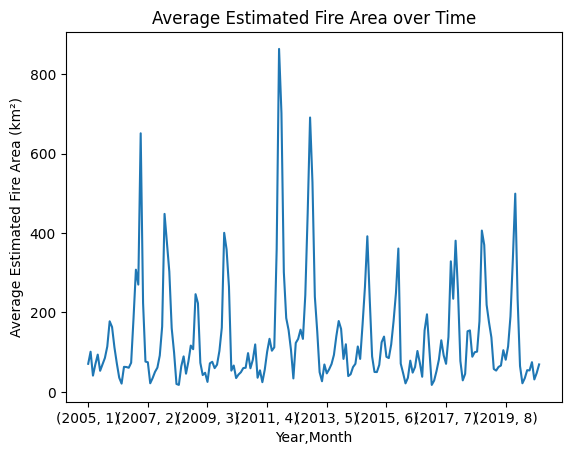

In [10]:
df_ym.plot(kind='line')
plt.xlabel('Year,Month')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Average Estimated Fire Area over Time')
plt.show()

In [11]:
df['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

Text(0.5, 1.0, 'Mean Estimated Fire Brightness Per Region')

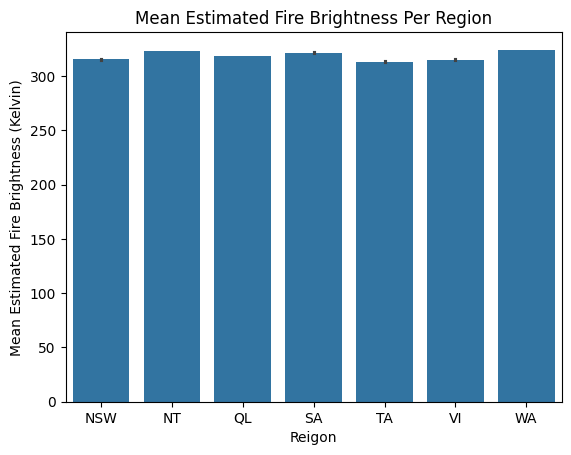

In [12]:
sns.barplot(data=df,x='Region', y='Mean_estimated_fire_brightness')
plt.xlabel('Reigon')
plt.ylabel("Mean Estimated Fire Brightness (Kelvin)")
plt.title("Mean Estimated Fire Brightness Per Region")

In [13]:
df_reg = df.groupby('Region')['Count'].sum()
df_reg

Region
NSW    117412
NT     649430
QL     420882
SA      35160
TA      11473
VI      52473
WA     615968
Name: Count, dtype: int64

(np.float64(-1.0999988337370465),
 np.float64(1.099999944463669),
 np.float64(-1.0999999060180037),
 np.float64(1.0999991308757453))

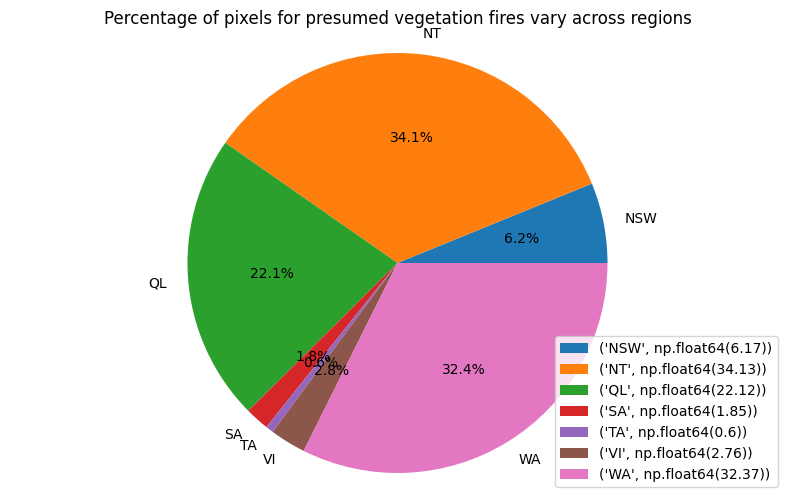

In [14]:
plt.figure(figsize=(10, 6))
plt.pie(df_reg,labels=df_reg.index ,autopct='%1.1f%%')
plt.title('Percentage of pixels for presumed vegetation fires vary across regions')
plt.legend([(i,round(k/df_reg.sum()*100,2)) for i,k in zip(df_reg.index, df_reg)])
plt.axis('equal')

Text(0.5, 1.0, 'Distribution of Mean Estimated Fire Brightness')

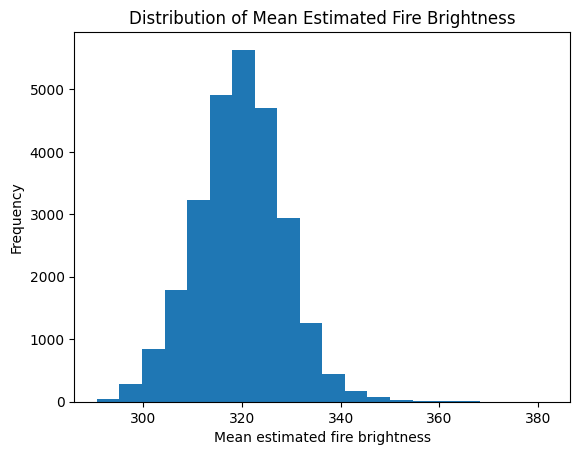

In [15]:
plt.hist(x=df['Mean_estimated_fire_brightness'],bins=20)
plt.xlabel('Mean estimated fire brightness')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Estimated Fire Brightness')

Text(0.5, 1.0, 'Distribution of Mean estimated fire brightness based on Region')

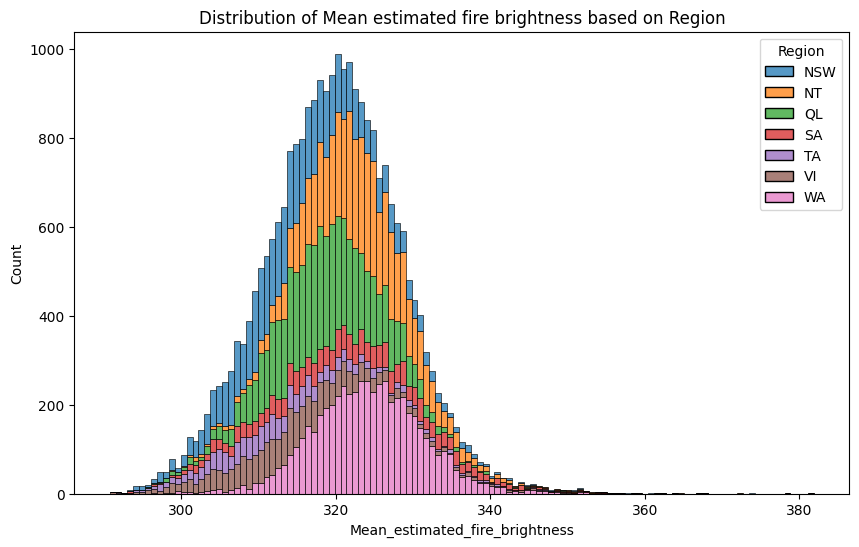

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,hue='Region',x='Mean_estimated_fire_brightness',multiple ='stack')
plt.title('Distribution of Mean estimated fire brightness based on Region')

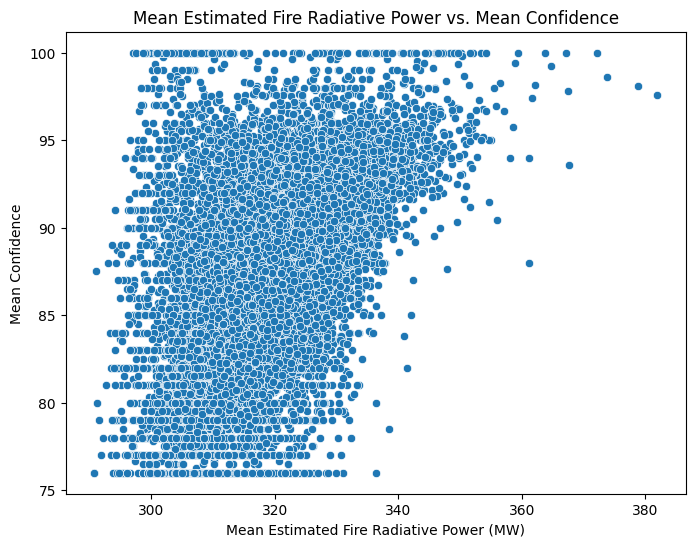

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Mean_estimated_fire_brightness',y='Mean_confidence')
plt.xlabel('Mean Estimated Fire Radiative Power (MW)')
plt.ylabel('Mean Confidence')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.show()

In [18]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [19]:
australia_map = folium.Map(location=[-25,135],zoom_start=4)
australia_map

In [22]:
australia_region = folium.map.FeatureGroup()

for lat , lon , lab in zip(reg.Lat,reg.Lon,reg.region):
    australia_region.add_child(
        folium.features.CircleMarker(
            [lat,lon],
            popup = lab,
            radius = 5,
            color = 'red',
            fill = True,
            fill_color = 'black',
            fill_opacity = 0.6
            
        )
    )
    
    
australia_map.add_child(australia_region)